## PROJECT 4: Regularization Techniques### 
Techniques: Dropout, L2 Regularization, Batch Normalization, Early Stoppin""

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("Loading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

Loading MNIST dataset...


In [3]:
# Normalize
x_train = x_train.reshape(-1, 784).astype('float32') / 255
x_test = x_test.reshape(-1, 784).astype('float32') / 255

In [4]:
# Use subset to demonstrate overfitting
x_train_small = x_train[:5000]
y_train_small = y_train[:5000]

In [5]:
print(f"Using {len(x_train_small)} training samples")

Using 5000 training samples


In [6]:
# Model WITHOUT regularization
print("\n1. Training model WITHOUT regularization...")
model_no_reg = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])


1. Training model WITHOUT regularization...


C:\Users\Shridhar\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model_no_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history_no_reg = model_no_reg.fit(
    x_train_small, y_train_small,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    verbose=0
)
print("Training complete!")

Training complete!


In [10]:
# Model WITH regularization
print("\n2. Training model WITH regularization...")
model_with_reg = models.Sequential([
    # First layer with L2 regularization
    layers.Dense(512, activation='relu',
                kernel_regularizer=keras.regularizers.l2(0.001),
                input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    # Second layer
    layers.Dense(256, activation='relu',
                kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Output layer
    layers.Dense(10, activation='softmax')
])


2. Training model WITH regularization...


In [11]:
model_with_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Early stopping callback
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_with_reg = model_with_reg.fit(
    x_train_small, y_train_small,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print("Training complete!")

Training complete!


In [13]:
# Compare results
print("\n" + "="*60)
print("RESULTS COMPARISON:")
print("="*60)


RESULTS COMPARISON:


In [14]:
# Without regularization
train_acc_no_reg = history_no_reg.history['accuracy'][-1]
val_acc_no_reg = history_no_reg.history['val_accuracy'][-1]
gap_no_reg = train_acc_no_reg - val_acc_no_reg

In [15]:
print(f"\nWithout Regularization:")
print(f"  Training Accuracy:   {train_acc_no_reg:.4f}")
print(f"  Validation Accuracy: {val_acc_no_reg:.4f}")
print(f"  Gap (Overfitting):   {gap_no_reg:.4f}")



Without Regularization:
  Training Accuracy:   1.0000
  Validation Accuracy: 0.9490
  Gap (Overfitting):   0.0510


In [16]:
# With regularization
train_acc_with_reg = history_with_reg.history['accuracy'][-1]
val_acc_with_reg = history_with_reg.history['val_accuracy'][-1]
gap_with_reg = train_acc_with_reg - val_acc_with_reg

In [17]:
print(f"\nWith Regularization:")
print(f"  Training Accuracy:   {train_acc_with_reg:.4f}")
print(f"  Validation Accuracy: {val_acc_with_reg:.4f}")
print(f"  Gap (Overfitting):   {gap_with_reg:.4f}")


With Regularization:
  Training Accuracy:   0.9747
  Validation Accuracy: 0.9360
  Gap (Overfitting):   0.0387


In [18]:
print(f"\n✓ Overfitting reduced by: {(gap_no_reg - gap_with_reg):.4f}")


✓ Overfitting reduced by: 0.0123


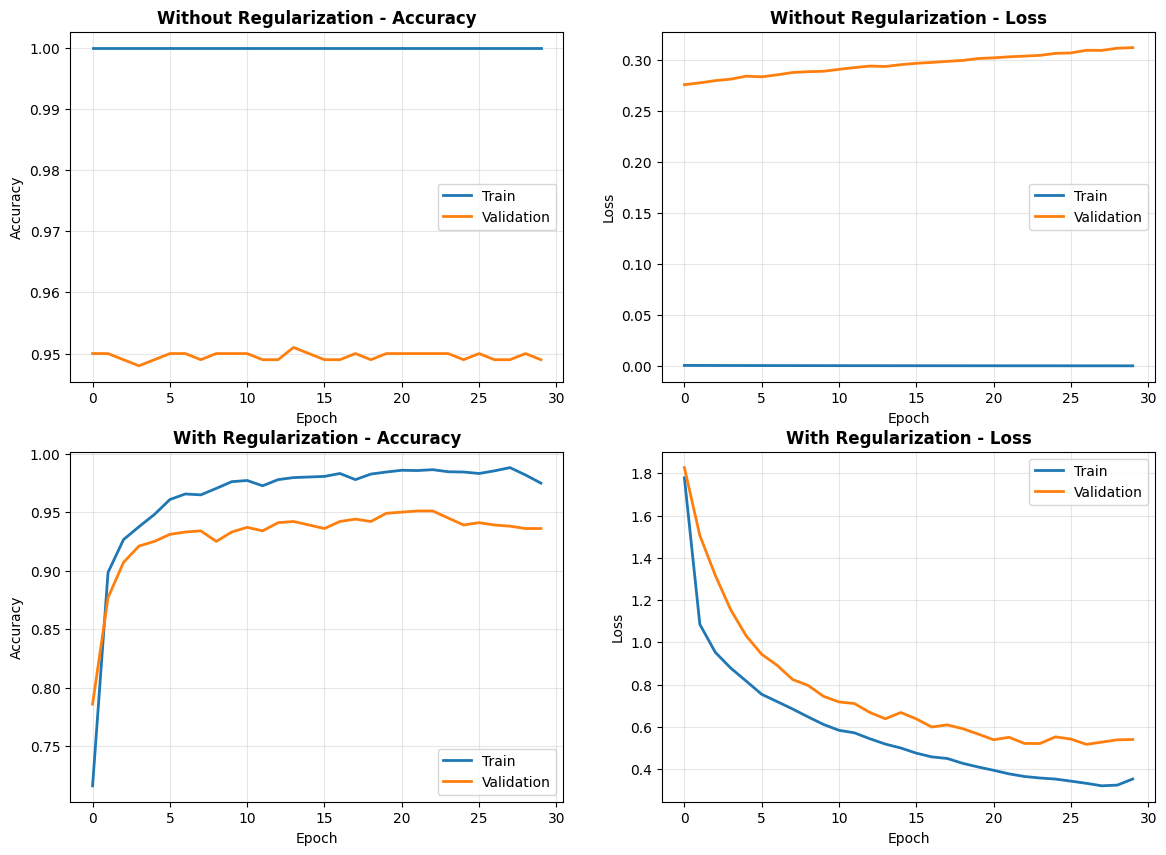

In [20]:
# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Without regularization - Accuracy
axes[0, 0].plot(history_no_reg.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history_no_reg.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_title('Without Regularization - Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Without regularization - Loss
axes[0, 1].plot(history_no_reg.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history_no_reg.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('Without Regularization - Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# With regularization - Accuracy
axes[1, 0].plot(history_with_reg.history['accuracy'], label='Train', linewidth=2)
axes[1, 0].plot(history_with_reg.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 0].set_title('With Regularization - Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# With regularization - Loss
axes[1, 1].plot(history_with_reg.history['loss'], label='Train', linewidth=2)
axes[1, 1].plot(history_with_reg.history['val_loss'], label='Validation', linewidth=2)
axes[1, 1].set_title('With Regularization - Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

In [21]:
plt.tight_layout()
plt.savefig('regularization_comparison.png', dpi=150)
print("\nPlot saved as 'regularization_comparison.png'")


Plot saved as 'regularization_comparison.png'


<Figure size 640x480 with 0 Axes>

In [22]:
print("\n" + "="*60)
print("REGULARIZATION TECHNIQUES EXPLAINED:")
print("="*60)
print("1. Dropout: Randomly drops neurons during training")
print("2. L2 Regularization: Penalizes large weights")
print("3. Batch Normalization: Normalizes layer inputs")
print("4. Early Stopping: Stops training when validation stops improving")
print("\n✓ Notice the smaller gap between train and validation accuracy!")


REGULARIZATION TECHNIQUES EXPLAINED:
1. Dropout: Randomly drops neurons during training
2. L2 Regularization: Penalizes large weights
3. Batch Normalization: Normalizes layer inputs
4. Early Stopping: Stops training when validation stops improving

✓ Notice the smaller gap between train and validation accuracy!
